# Cetakia Best Model V2 - Evaluation Visualization

Notebook ini dibuat untuk evaluasi **realistis** kondisi model Best Model V2 saat ini: fokus ke kualitas ekstraksi field, robust-ness error pattern, dan performa latency untuk produksi.

## Tujuan Evaluasi
- Mengukur akurasi ekstraksi per-field dan overall terhadap ground truth.
- Mengukur latency aktual dan gap terhadap target produksi (`< 1s`).
- Menganalisis error secara terstruktur: `miss`, `wrong_value`, `over_extract`, template-level risk.
- Menampilkan hard cases prioritas untuk debugging model.

## Snapshot Kondisi Terakhir (Run Lokal, 20 Mei 2026, 100 sampel)
- Overall accuracy: **85.43%**
- Per-field accuracy: `reference_no=75.36%`, `transaction_date=68.54%`, `account_no=92.71%`, `recipient_name=89.90%`, `total_amount=96.00%`
- Latency: mean **1.3745s**, p95 **2.1217s**, max **2.5871s**

> Notebook ini akan menghitung ulang metrik dari data aktual project agar hasil tetap sinkron dengan kondisi model saat dijalankan.


In [1]:
import json
import math
import statistics
import time
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image, ImageDraw, ImageFont
from IPython.display import display, Markdown

import sys

ROOT = Path.cwd().resolve()
if not (ROOT / 'src_v2').exists():
    if (ROOT.parent / 'src_v2').exists():
        ROOT = ROOT.parent
    else:
        raise RuntimeError('Jalankan notebook dari root project atau folder src_v2')

if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from src_v2.config import GROUND_TRUTH_PATH, IMAGE_DIR, FIELDS, TARGET_LATENCY_SECONDS
from src_v2.evaluate_v2 import load_rows, is_match, normalize_field_value, evaluate as evaluate_script
from src_v2.inference_v2 import ReceiptFieldExtractorV2

print('Project root :', ROOT)
print('Ground truth :', GROUND_TRUTH_PATH)
print('Image folder :', IMAGE_DIR)
print('Fields       :', FIELDS)


Project root : /home/zen/Documents/Cetakia/cetakia-field-extraction-v2
Ground truth : /home/zen/Documents/Cetakia/cetakia-field-extraction-v2/data/ground_truth.jsonl
Image folder : /home/zen/Documents/Cetakia/cetakia-field-extraction-v2/data/images
Fields       : ['reference_no', 'transaction_date', 'account_no', 'recipient_name', 'total_amount']


In [2]:
# Konfigurasi evaluasi
SAMPLE_LIMIT = 100         # None = evaluasi semua sampel
FORCE_RERUN = True         # True = hitung ulang fresh (disarankan setelah code model berubah)
AUTO_INVALIDATE_CACHE = True  # invalidasi cache jika parser/inference berubah
VERIFY_WITH_TERMINAL = True  # jalankan evaluator terminal sebagai sanity check konsistensi

ACCURACY_TARGET = 0.85     # target minimum per objective
LATENCY_TARGET = 1.0       # target latency produksi

OUT_DIR = ROOT / 'artifacts_v2' / 'evaluation_visuals_v2'
OUT_DIR.mkdir(parents=True, exist_ok=True)

suffix = str(SAMPLE_LIMIT) if SAMPLE_LIMIT is not None else 'all'
FIELD_CSV = OUT_DIR / f'field_level_{suffix}.csv'
ROW_CSV = OUT_DIR / f'row_level_{suffix}.csv'
SUMMARY_JSON = OUT_DIR / f'summary_{suffix}.json'

MODEL_DEPENDENCY_FILES = [
    ROOT / 'src_v2' / 'rule_parser_v1.py',
    ROOT / 'src_v2' / 'inference_v2.py',
    ROOT / 'src_v2' / 'candidate_generator.py',
    ROOT / 'src_v2' / 'feature_builder.py',
    ROOT / 'src_v2' / 'template_router.py',
    ROOT / 'src_v2' / 'layout_parser.py',
    ROOT / 'src_v2' / 'ocr_engine.py',
]

print('Output dir   :', OUT_DIR)
print('Sample limit :', SAMPLE_LIMIT)
print('Force rerun  :', FORCE_RERUN)


Output dir   : /home/zen/Documents/Cetakia/cetakia-field-extraction-v2/artifacts_v2/evaluation_visuals_v2
Sample limit : 100
Force rerun  : True


In [3]:
def classify_status(gt_value, pred_value, matched):
    gt_none = gt_value is None
    pred_none = pred_value is None

    if gt_none and pred_none:
        return 'true_null'
    if gt_none and not pred_none:
        return 'over_extract'
    if (not gt_none) and pred_none:
        return 'miss_empty'
    if matched:
        return 'correct'
    return 'wrong_value'


def evaluate_detailed(limit=None):
    rows = load_rows(Path(GROUND_TRUTH_PATH))
    if limit is not None:
        rows = rows[:limit]

    extractor = ReceiptFieldExtractorV2()

    field_rows = []
    row_rows = []

    for i, row in enumerate(rows, start=1):
        image_name = row['image']
        gt = row.get('ground_truth', {})
        image_path = Path(IMAGE_DIR) / image_name

        pred = {}
        confidence_map = {}
        source_map = {}
        needs_review_map = {}
        template = 'unknown'
        template_score = 0.0

        t0 = time.perf_counter()
        error_text = None

        try:
            output = extractor.predict(str(image_path), return_meta=True)
            pred = output.get('data', {}) or {}
            confidence_map = output.get('confidence', {}) or {}
            source_map = output.get('source', {}) or {}
            needs_review_map = output.get('needs_review', {}) or {}
            template = output.get('template', 'unknown')
            template_score = float(output.get('template_score', 0.0) or 0.0)
            latency = float(output.get('latency_seconds', time.perf_counter() - t0) or 0.0)
        except Exception as exc:
            latency = float(time.perf_counter() - t0)
            template = 'error'
            template_score = 0.0
            error_text = str(exc)

        row_total = 0
        row_correct = 0

        for field in FIELDS:
            gt_value = gt.get(field)
            pred_value = pred.get(field)

            has_gt = gt_value is not None
            matched = bool(is_match(field, pred_value, gt_value)) if has_gt else False
            status = classify_status(gt_value, pred_value, matched)

            if has_gt:
                row_total += 1
                if matched:
                    row_correct += 1

            field_rows.append({
                'image': image_name,
                'field': field,
                'gt_raw': gt_value,
                'pred_raw': pred_value,
                'gt_norm': normalize_field_value(field, gt_value) if gt_value is not None else None,
                'pred_norm': normalize_field_value(field, pred_value) if pred_value is not None else None,
                'has_gt': has_gt,
                'match': matched if has_gt else np.nan,
                'status': status,
                'confidence': float(confidence_map.get(field, 0.0) or 0.0),
                'needs_review': bool(needs_review_map.get(field, False)),
                'source': source_map.get(field, 'none'),
                'template': template,
                'template_score': template_score,
                'latency_seconds': latency,
                'error': error_text,
            })

        row_rows.append({
            'image': image_name,
            'template': template,
            'template_score': template_score,
            'latency_seconds': latency,
            'field_total': row_total,
            'field_correct': row_correct,
            'row_accuracy': (row_correct / row_total) if row_total else np.nan,
            'error': error_text,
        })

        if i % 10 == 0 or i == len(rows):
            print(f'Processed {i}/{len(rows)} samples')

    df_field = pd.DataFrame(field_rows)
    df_row = pd.DataFrame(row_rows)
    return df_field, df_row


In [4]:
cache_available = FIELD_CSV.exists() and ROW_CSV.exists()
cache_is_stale = False
stale_reasons = []
run_source = 'fresh_run'

if cache_available and AUTO_INVALIDATE_CACHE:
    cache_ts = min(FIELD_CSV.stat().st_mtime, ROW_CSV.stat().st_mtime)
    for dep in MODEL_DEPENDENCY_FILES:
        if not dep.exists():
            continue
        if dep.stat().st_mtime > cache_ts:
            cache_is_stale = True
            stale_reasons.append(dep.name)

if FORCE_RERUN:
    cache_is_stale = True
    stale_reasons.append('FORCE_RERUN=True')

if cache_available and (not cache_is_stale):
    run_source = 'cache'
    print('Load cached evaluation from CSV ...')
    df_field = pd.read_csv(FIELD_CSV)
    df_row = pd.read_csv(ROW_CSV)
else:
    if cache_available and cache_is_stale:
        print('Cache invalidated. Re-run evaluation pipeline ...')
        if stale_reasons:
            print('Stale reasons:', ', '.join(sorted(set(stale_reasons))))
    else:
        print('Run full evaluation pipeline ...')

    df_field, df_row = evaluate_detailed(limit=SAMPLE_LIMIT)

    df_field.to_csv(FIELD_CSV, index=False)
    df_row.to_csv(ROW_CSV, index=False)
    print('Saved cache:')
    print('-', FIELD_CSV)
    print('-', ROW_CSV)

# Normalisasi dtype setelah load / rerun
if 'has_gt' in df_field.columns:
    df_field['has_gt'] = df_field['has_gt'].astype(str).str.lower().isin(['true', '1'])
if 'needs_review' in df_field.columns:
    df_field['needs_review'] = df_field['needs_review'].astype(str).str.lower().isin(['true', '1'])
if 'match' in df_field.columns:
    df_field['match'] = pd.to_numeric(df_field['match'], errors='coerce')
if 'confidence' in df_field.columns:
    df_field['confidence'] = pd.to_numeric(df_field['confidence'], errors='coerce')
if 'latency_seconds' in df_field.columns:
    df_field['latency_seconds'] = pd.to_numeric(df_field['latency_seconds'], errors='coerce')
if 'latency_seconds' in df_row.columns:
    df_row['latency_seconds'] = pd.to_numeric(df_row['latency_seconds'], errors='coerce')

print('Data source :', run_source)
print('Field rows  :', len(df_field))
print('Row rows    :', len(df_row))
if FIELD_CSV.exists() and ROW_CSV.exists():
    print('Field cache updated :', pd.Timestamp.fromtimestamp(FIELD_CSV.stat().st_mtime))
    print('Row cache updated   :', pd.Timestamp.fromtimestamp(ROW_CSV.stat().st_mtime))


Cache invalidated. Re-run evaluation pipeline ...
Stale reasons: FORCE_RERUN=True, candidate_generator.py, inference_v2.py, rule_parser_v1.py


/home/zen/miniconda3/envs/cetakia/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/zen/miniconda3/envs/cetakia/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator _BinMapper from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/zen/miniconda3/envs/cetakia/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator HistGradientBoostingClassifier fr

Processed 10/100 samples
Processed 20/100 samples
Processed 30/100 samples
Processed 40/100 samples
Processed 50/100 samples
Processed 60/100 samples
Processed 70/100 samples
Processed 80/100 samples
Processed 90/100 samples
Processed 100/100 samples
Saved cache:
- /home/zen/Documents/Cetakia/cetakia-field-extraction-v2/artifacts_v2/evaluation_visuals_v2/field_level_100.csv
- /home/zen/Documents/Cetakia/cetakia-field-extraction-v2/artifacts_v2/evaluation_visuals_v2/row_level_100.csv
Data source : fresh_run
Field rows  : 500
Row rows    : 100
Field cache updated : 2026-05-21 15:00:51.444451
Row cache updated   : 2026-05-21 15:00:51.444451


In [5]:
eval_df = df_field[df_field['has_gt'] == True].copy()

per_field = (
    eval_df.groupby('field', as_index=False)
    .agg(
        total=('match', 'size'),
        correct=('match', lambda s: int(np.nansum(s))),
        accuracy=('match', lambda s: float(np.nanmean(s))),
        avg_confidence=('confidence', 'mean'),
        review_rate=('needs_review', 'mean'),
    )
    .sort_values('accuracy', ascending=True)
)

overall_accuracy = float(np.nanmean(eval_df['match'])) if len(eval_df) else float('nan')

lat = df_row['latency_seconds'].dropna().astype(float)
latency_summary = {
    'mean': float(lat.mean()) if len(lat) else float('nan'),
    'median': float(lat.median()) if len(lat) else float('nan'),
    'p90': float(lat.quantile(0.90)) if len(lat) else float('nan'),
    'p95': float(lat.quantile(0.95)) if len(lat) else float('nan'),
    'p99': float(lat.quantile(0.99)) if len(lat) else float('nan'),
    'max': float(lat.max()) if len(lat) else float('nan'),
    'under_1s_ratio': float((lat < LATENCY_TARGET).mean()) if len(lat) else float('nan'),
}

summary = {
    'samples': int(df_row.shape[0]),
    'overall_accuracy': round(overall_accuracy, 4),
    'latency': {k: round(v, 4) if pd.notna(v) else None for k, v in latency_summary.items()},
    'per_field': {
        row['field']: {
            'total': int(row['total']),
            'correct': int(row['correct']),
            'accuracy': round(float(row['accuracy']), 4),
            'avg_confidence': round(float(row['avg_confidence']), 4),
            'review_rate': round(float(row['review_rate']), 4),
        }
        for _, row in per_field.iterrows()
    },
    'targets': {
        'accuracy_target': ACCURACY_TARGET,
        'latency_target': LATENCY_TARGET,
    },
}

with SUMMARY_JSON.open('w', encoding='utf-8') as fp:
    json.dump(summary, fp, indent=2, ensure_ascii=False)

print('Summary JSON saved:', SUMMARY_JSON)

kpi_table = pd.DataFrame([
    {'metric': 'samples', 'value': summary['samples']},
    {'metric': 'overall_accuracy', 'value': summary['overall_accuracy']},
    {'metric': 'latency_mean_sec', 'value': summary['latency']['mean']},
    {'metric': 'latency_p95_sec', 'value': summary['latency']['p95']},
    {'metric': 'latency_max_sec', 'value': summary['latency']['max']},
    {'metric': 'latency_under_1s_ratio', 'value': summary['latency']['under_1s_ratio']},
])

display(Markdown('### KPI Ringkas'))
display(kpi_table)

display(Markdown('### Akurasi Per Field'))
display(
    per_field.assign(
        accuracy_pct=lambda d: (d['accuracy'] * 100).round(2),
        avg_confidence=lambda d: d['avg_confidence'].round(3),
        review_rate_pct=lambda d: (d['review_rate'] * 100).round(2),
    )[['field', 'total', 'correct', 'accuracy_pct', 'avg_confidence', 'review_rate_pct']]
)

# Sanity check terhadap evaluator terminal (src_v2/evaluate_v2.py)
if VERIFY_WITH_TERMINAL:
    terminal_metrics = evaluate_script(limit=SAMPLE_LIMIT)
    terminal_comp = pd.DataFrame([
        {'metric': 'overall_accuracy', 'notebook': summary['overall_accuracy'], 'terminal': terminal_metrics['overall_accuracy']},
        {'metric': 'latency_mean', 'notebook': summary['latency']['mean'], 'terminal': terminal_metrics['latency']['mean']},
        {'metric': 'latency_p95', 'notebook': summary['latency']['p95'], 'terminal': terminal_metrics['latency']['p95']},
        {'metric': 'latency_max', 'notebook': summary['latency']['max'], 'terminal': terminal_metrics['latency']['max']},
    ])

    for f in FIELDS:
        terminal_comp = pd.concat([
            terminal_comp,
            pd.DataFrame([{
                'metric': f'field_{f}',
                'notebook': summary['per_field'].get(f, {}).get('accuracy'),
                'terminal': terminal_metrics['per_field'].get(f, {}).get('accuracy'),
            }])
        ], ignore_index=True)

    terminal_comp['delta'] = pd.to_numeric(terminal_comp['notebook'], errors='coerce') - pd.to_numeric(terminal_comp['terminal'], errors='coerce')

    display(Markdown('### Sanity Check Notebook vs Terminal Evaluator'))
    display(terminal_comp)
else:
    display(Markdown('### Sanity Check Notebook vs Terminal Evaluator'))
    display(Markdown('Sanity check dinonaktifkan (`VERIFY_WITH_TERMINAL=False`).'))


Summary JSON saved: /home/zen/Documents/Cetakia/cetakia-field-extraction-v2/artifacts_v2/evaluation_visuals_v2/summary_100.json


### KPI Ringkas

,metric,value
0,samples,100.0000
1,overall_accuracy,0.9360
2,latency_mean_sec,1.8726
3,latency_p95_sec,2.6268
4,latency_max_sec,3.5579
5,latency_under_1s_ratio,0.0200


### Akurasi Per Field

,field,total,correct,accuracy_pct,avg_confidence,review_rate_pct
4,transaction_date,89,77,86.52,0.841,2.25
2,reference_no,69,62,89.86,0.967,0.00
0,account_no,96,89,92.71,0.876,6.25
1,recipient_name,99,97,97.98,0.931,2.02
3,total_amount,100,99,99.00,0.926,0.00


/home/zen/miniconda3/envs/cetakia/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/zen/miniconda3/envs/cetakia/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator _BinMapper from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/zen/miniconda3/envs/cetakia/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator HistGradientBoostingClassifier fr

### Sanity Check Notebook vs Terminal Evaluator

,metric,notebook,terminal,delta
0,overall_accuracy,0.9360,0.9360,0.0000
1,latency_mean,1.8726,1.8590,0.0136
2,latency_p95,2.6268,2.7634,-0.1366
3,latency_max,3.5579,3.6480,-0.0901
4,field_reference_no,0.8986,0.8986,0.0000
5,field_transaction_date,0.8652,0.8652,0.0000
6,field_account_no,0.9271,0.9271,0.0000
7,field_recipient_name,0.9798,0.9798,0.0000
8,field_total_amount,0.9900,0.9900,0.0000


In [6]:
def get_font(size=16, bold=False):
    # Fallback font agar stabil di Linux environment
    candidates = [
        '/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf' if bold else '/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf',
        '/usr/share/fonts/dejavu/DejaVuSans-Bold.ttf' if bold else '/usr/share/fonts/dejavu/DejaVuSans.ttf',
    ]
    for fp in candidates:
        try:
            return ImageFont.truetype(fp, size=size)
        except Exception:
            continue
    return ImageFont.load_default()


def draw_text(draw, x, y, text, font, fill=(25, 25, 25)):
    draw.text((x, y), str(text), font=font, fill=fill)


def save_and_show(img, filename):
    path = OUT_DIR / filename
    img.save(path)
    display(img)
    print('Saved:', path)


def draw_accuracy_bar(per_field_df, target=0.85):
    df = per_field_df.sort_values('accuracy', ascending=True).reset_index(drop=True)

    W, H = 1220, 560
    left, right, top, bottom = 260, 80, 100, 60
    plot_w = W - left - right
    n = len(df)
    row_h = (H - top - bottom) / max(n, 1)

    img = Image.new('RGB', (W, H), 'white')
    d = ImageDraw.Draw(img)

    title_font = get_font(26, bold=True)
    label_font = get_font(18, bold=False)
    small_font = get_font(14, bold=False)

    draw_text(d, 24, 24, 'Field Accuracy vs Target', title_font)
    draw_text(d, 24, 60, f'Target >= {target*100:.1f}%', small_font, fill=(70, 70, 70))

    # Axis line
    y_axis = top - 10
    d.line((left, y_axis, left + plot_w, y_axis), fill=(180, 180, 180), width=1)

    # Target line
    tx = left + int(target * plot_w)
    d.line((tx, top - 16, tx, H - bottom + 6), fill=(255, 120, 0), width=3)
    draw_text(d, tx + 6, top - 34, 'target', small_font, fill=(255, 120, 0))

    for i, row in df.iterrows():
        y0 = int(top + i * row_h + 8)
        y1 = int(top + (i + 1) * row_h - 8)
        acc = float(row['accuracy'])
        x1 = left + int(max(0.0, min(1.0, acc)) * plot_w)

        # background lane
        d.rectangle((left, y0, left + plot_w, y1), fill=(246, 246, 246), outline=(235, 235, 235))

        # value bar
        if acc >= target:
            color = (50, 170, 90)
        elif acc >= target - 0.08:
            color = (246, 162, 45)
        else:
            color = (220, 85, 70)
        d.rectangle((left, y0, x1, y1), fill=color)

        draw_text(d, 18, y0 + 2, row['field'], label_font)
        draw_text(d, left + plot_w + 12, y0 + 2, f"{acc*100:.2f}% ({int(row['correct'])}/{int(row['total'])})", label_font)

    return img


def draw_latency_hist_cdf(latencies, target=1.0, bins=12):
    values = np.asarray(list(latencies), dtype=float)
    values = values[np.isfinite(values)]
    if len(values) == 0:
        return Image.new('RGB', (1220, 540), 'white')

    hist, edges = np.histogram(values, bins=bins)
    cdf = np.cumsum(hist) / np.sum(hist)

    W, H = 1220, 560
    left, right, top, bottom = 110, 130, 90, 80
    plot_w = W - left - right
    plot_h = H - top - bottom

    img = Image.new('RGB', (W, H), 'white')
    d = ImageDraw.Draw(img)

    title_font = get_font(26, bold=True)
    label_font = get_font(16, bold=False)
    small_font = get_font(13, bold=False)

    draw_text(d, 24, 20, 'Latency Distribution and CDF', title_font)
    draw_text(d, 24, 56, f'Target latency < {target:.2f}s', small_font, fill=(70, 70, 70))

    # axes
    d.line((left, top, left, top + plot_h), fill=(110, 110, 110), width=2)
    d.line((left, top + plot_h, left + plot_w, top + plot_h), fill=(110, 110, 110), width=2)

    max_hist = max(int(hist.max()), 1)
    n_bins = len(hist)
    bar_w = plot_w / max(n_bins, 1)

    # histogram bars
    for i, c in enumerate(hist):
        x0 = int(left + i * bar_w + 2)
        x1 = int(left + (i + 1) * bar_w - 2)
        h = int((c / max_hist) * plot_h)
        y0 = top + plot_h - h
        y1 = top + plot_h
        d.rectangle((x0, y0, x1, y1), fill=(117, 179, 245), outline=(82, 144, 212))

    # cdf line (scaled to same plot area)
    pts = []
    for i, c in enumerate(cdf):
        x = int(left + (i + 0.5) * bar_w)
        y = int(top + plot_h - c * plot_h)
        pts.append((x, y))
    if len(pts) > 1:
        d.line(pts, fill=(227, 74, 51), width=3)

    # target line
    x_target = int(left + ((target - edges[0]) / max(edges[-1] - edges[0], 1e-9)) * plot_w)
    x_target = max(left, min(left + plot_w, x_target))
    d.line((x_target, top - 6, x_target, top + plot_h + 6), fill=(255, 140, 0), width=3)
    draw_text(d, x_target + 6, top - 26, '1.0s target', small_font, fill=(255, 140, 0))

    # x ticks
    for t in np.linspace(edges[0], edges[-1], 6):
        x = int(left + ((t - edges[0]) / max(edges[-1] - edges[0], 1e-9)) * plot_w)
        d.line((x, top + plot_h, x, top + plot_h + 6), fill=(110, 110, 110), width=1)
        draw_text(d, x - 16, top + plot_h + 10, f'{t:.2f}', small_font, fill=(70, 70, 70))

    # y labels
    draw_text(d, 14, top - 6, 'Count', small_font, fill=(70, 70, 70))
    draw_text(d, W - 72, top - 6, 'CDF', small_font, fill=(70, 70, 70))
    draw_text(d, W - 72, top + plot_h - 12, '0%', small_font, fill=(70, 70, 70))
    draw_text(d, W - 76, top - 12, '100%', small_font, fill=(70, 70, 70))

    return img


def draw_template_field_heatmap(df_eval, top_k_templates=8):
    # failure rate hanya untuk field yang punya GT
    work = df_eval[df_eval['has_gt'] == True].copy()
    if len(work) == 0:
        return Image.new('RGB', (1220, 560), 'white')

    top_templates = (
        work.groupby('template').size().sort_values(ascending=False).head(top_k_templates).index.tolist()
    )
    work = work[work['template'].isin(top_templates)]

    pivot = (
        work.groupby(['field', 'template'])['match']
        .mean()
        .unstack(fill_value=np.nan)
    )

    fail = 1.0 - pivot
    fail = fail.reindex(index=FIELDS)

    fields = list(fail.index)
    templates = list(fail.columns)

    W, H = 1220, 620
    left, right, top, bottom = 290, 40, 120, 80
    grid_w = W - left - right
    grid_h = H - top - bottom

    n_rows = max(len(fields), 1)
    n_cols = max(len(templates), 1)
    cell_w = grid_w / n_cols
    cell_h = grid_h / n_rows

    img = Image.new('RGB', (W, H), 'white')
    d = ImageDraw.Draw(img)

    title_font = get_font(24, bold=True)
    label_font = get_font(14, bold=False)
    small_font = get_font(12, bold=False)

    draw_text(d, 24, 24, 'Template vs Field Failure Rate (Top Template Volume)', title_font)
    draw_text(d, 24, 58, 'Hijau = lebih baik, Merah = lebih berisiko', small_font, fill=(70, 70, 70))

    for r, field in enumerate(fields):
        y0 = top + r * cell_h
        y1 = top + (r + 1) * cell_h
        draw_text(d, 20, int((y0 + y1) / 2 - 8), field, label_font)

        for c, tmpl in enumerate(templates):
            x0 = left + c * cell_w
            x1 = left + (c + 1) * cell_w

            val = fail.loc[field, tmpl]
            if pd.isna(val):
                color = (245, 245, 245)
                txt = '-'
            else:
                v = max(0.0, min(1.0, float(val)))
                # gradient green -> yellow -> red
                if v < 0.5:
                    rr = int(60 + 360 * v)
                    gg = int(170 + 70 * (0.5 - v) / 0.5)
                    bb = 90
                else:
                    rr = 230
                    gg = int(170 - 170 * (v - 0.5) / 0.5)
                    bb = 85
                color = (max(0, min(255, rr)), max(0, min(255, gg)), bb)
                txt = f'{v*100:.1f}%'

            d.rectangle((x0, y0, x1, y1), fill=color, outline=(230, 230, 230))
            draw_text(d, int(x0 + 8), int(y0 + cell_h / 2 - 8), txt, small_font, fill=(20, 20, 20))

    for c, tmpl in enumerate(templates):
        x0 = left + c * cell_w
        draw_text(d, int(x0 + 4), top - 26, str(tmpl)[:24], small_font, fill=(50, 50, 50))

    return img


### Visual 1 - Field Accuracy

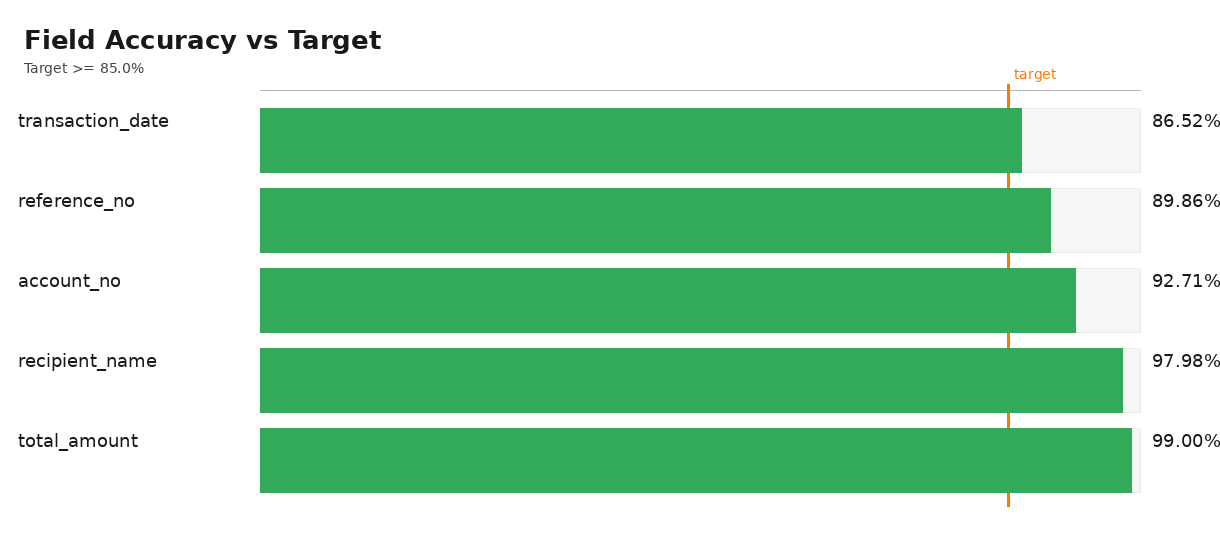

Saved: /home/zen/Documents/Cetakia/cetakia-field-extraction-v2/artifacts_v2/evaluation_visuals_v2/chart_field_accuracy_100.png


### Visual 2 - Latency Histogram + CDF

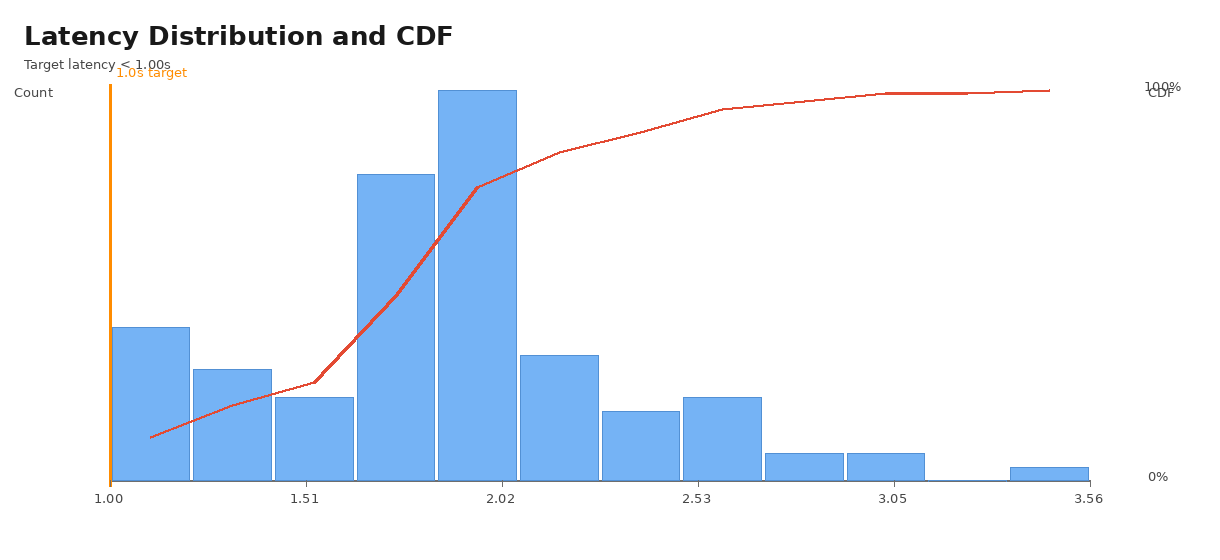

Saved: /home/zen/Documents/Cetakia/cetakia-field-extraction-v2/artifacts_v2/evaluation_visuals_v2/chart_latency_100.png


### Visual 3 - Template x Field Failure Heatmap

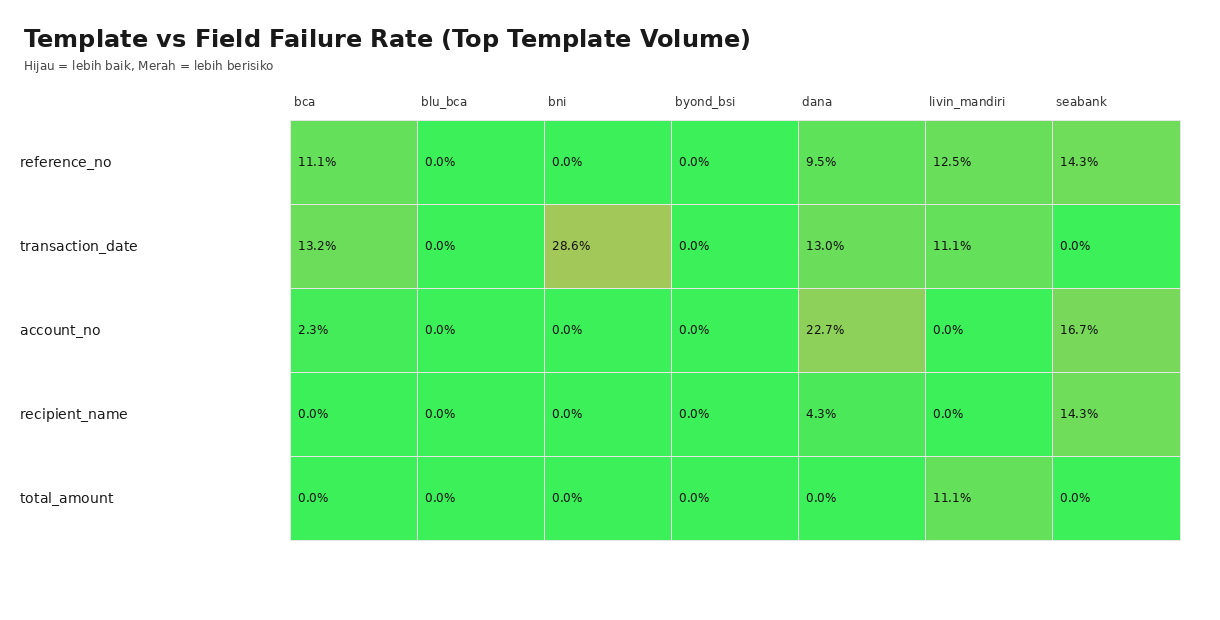

Saved: /home/zen/Documents/Cetakia/cetakia-field-extraction-v2/artifacts_v2/evaluation_visuals_v2/chart_template_field_heatmap_100.png


In [7]:
display(Markdown('### Visual 1 - Field Accuracy'))
img_acc = draw_accuracy_bar(per_field, target=ACCURACY_TARGET)
save_and_show(img_acc, f'chart_field_accuracy_{suffix}.png')


display(Markdown('### Visual 2 - Latency Histogram + CDF'))
img_lat = draw_latency_hist_cdf(df_row['latency_seconds'].values, target=LATENCY_TARGET, bins=12)
save_and_show(img_lat, f'chart_latency_{suffix}.png')


display(Markdown('### Visual 3 - Template x Field Failure Heatmap'))
img_heat = draw_template_field_heatmap(df_field, top_k_templates=8)
save_and_show(img_heat, f'chart_template_field_heatmap_{suffix}.png')


In [8]:
display(Markdown('### Breakdown Error per Field'))
status_breakdown = (
    df_field[df_field['has_gt'] == True]
    .groupby(['field', 'status'])
    .size()
    .unstack(fill_value=0)
)
status_ratio = status_breakdown.div(status_breakdown.sum(axis=1), axis=0).round(4)

display(status_breakdown)
display((status_ratio * 100).round(2).add_suffix('_pct'))


display(Markdown('### Confidence Bucket vs Match Rate'))
conf_df = eval_df.copy()
conf_df['confidence_bucket'] = pd.cut(
    conf_df['confidence'].astype(float),
    bins=[-0.001, 0.4, 0.6, 0.75, 0.9, 1.0],
    labels=['0.00-0.40', '0.40-0.60', '0.60-0.75', '0.75-0.90', '0.90-1.00']
)

conf_table = (
    conf_df.groupby(['field', 'confidence_bucket'])['match']
    .agg(samples='size', match_rate='mean')
    .reset_index()
)
conf_table['match_rate_pct'] = (conf_table['match_rate'] * 100).round(2)
display(conf_table.sort_values(['field', 'confidence_bucket']))


display(Markdown('### Source Contribution (Rule vs Model Fallback)'))
source_mix = (
    eval_df.groupby(['field', 'source'])
    .size()
    .unstack(fill_value=0)
)
source_mix_ratio = source_mix.div(source_mix.sum(axis=1), axis=0).round(4)

display(source_mix)
display((source_mix_ratio * 100).round(2).add_suffix('_pct'))


### Breakdown Error per Field

status,correct,miss_empty,wrong_value
field,,,
account_no,89,5,2
recipient_name,97,0,2
reference_no,62,2,5
total_amount,99,0,1
transaction_date,77,2,10


status,correct_pct,miss_empty_pct,wrong_value_pct
field,,,
account_no,92.71,5.21,2.08
recipient_name,97.98,0.00,2.02
reference_no,89.86,2.90,7.25
total_amount,99.00,0.00,1.00
transaction_date,86.52,2.25,11.24


### Confidence Bucket vs Match Rate

/tmp/ipykernel_54921/46318397.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  conf_df.groupby(['field', 'confidence_bucket'])['match']


,field,confidence_bucket,samples,match_rate,match_rate_pct
0,account_no,0.00-0.40,5,0.000000,0.00
1,account_no,0.40-0.60,0,NaN,NaN
2,account_no,0.60-0.75,1,0.000000,0.00
3,account_no,0.75-0.90,38,0.973684,97.37
4,account_no,0.90-1.00,52,1.000000,100.00
5,recipient_name,0.00-0.40,0,NaN,NaN
6,recipient_name,0.40-0.60,0,NaN,NaN
7,recipient_name,0.60-0.75,2,0.500000,50.00
8,recipient_name,0.75-0.90,10,1.000000,100.00
9,recipient_name,0.90-1.00,87,0.988506,98.85


### Source Contribution (Rule vs Model Fallback)

source,account_recipient_map,model_fallback,none,rules_v1,rules_v1_explicit_null
field,,,,,
account_no,0,1,5,90,0
recipient_name,1,0,0,98,0
reference_no,0,0,0,67,2
total_amount,0,0,0,100,0
transaction_date,0,0,2,87,0


source,account_recipient_map_pct,model_fallback_pct,none_pct,rules_v1_pct,rules_v1_explicit_null_pct
field,,,,,
account_no,0.00,1.04,5.21,93.75,0.0
recipient_name,1.01,0.00,0.00,98.99,0.0
reference_no,0.00,0.00,0.00,97.10,2.9
total_amount,0.00,0.00,0.00,100.00,0.0
transaction_date,0.00,0.00,2.25,97.75,0.0


In [9]:
display(Markdown('### Hard Cases - Prioritas Debug'))
hard_rows = df_row.sort_values(['row_accuracy', 'latency_seconds'], ascending=[True, False]).head(15)
display(hard_rows[['image', 'template', 'row_accuracy', 'latency_seconds', 'field_correct', 'field_total', 'error']])

# detail field-level untuk 5 sample terburuk
worst_images = hard_rows['image'].head(5).tolist()
for img in worst_images:
    display(Markdown(f'#### Detail: `{img}`'))
    detail = df_field[df_field['image'] == img][[
        'field', 'status', 'gt_raw', 'pred_raw', 'confidence', 'source', 'latency_seconds'
    ]]
    display(detail)


### Hard Cases - Prioritas Debug

,image,template,row_accuracy,latency_seconds,field_correct,field_total,error
30,33.jpg,seabank,0.250000,1.8126,1,4,None
93,311.jpeg,dana,0.600000,2.0299,3,5,None
58,61.jpg,bca,0.666667,1.9571,2,3,None
36,39.jpg,livin_mandiri,0.750000,1.7676,3,4,None
3,5.jpg,None,0.750000,1.5838,3,4,None
48,51.jpg,bca,0.750000,1.2499,3,4,None
32,35.jpg,bca,0.750000,1.1346,3,4,None
49,52.jpg,bca,0.750000,0.9987,3,4,None
22,24.jpg,dana,0.800000,2.6224,4,5,None
91,164.png,dana,0.800000,2.3297,4,5,None


#### Detail: `33.jpg`

,field,status,gt_raw,pred_raw,confidence,source,latency_seconds
150,reference_no,wrong_value,2026040343505101608027237,BCA:7425262836,0.74,rules_v1,1.8126
151,transaction_date,true_null,None,None,0.00,none,1.8126
152,account_no,wrong_value,7425252836,901817655204,0.86,rules_v1,1.8126
153,recipient_name,wrong_value,Fadhil Bawazier,Vilia Pirdi Lianti,0.66,rules_v1,1.8126
154,total_amount,correct,50000,50000,0.84,rules_v1,1.8126


#### Detail: `311.jpeg`

...

,field,status,gt_raw,pred_raw,confidence,source,latency_seconds
290,reference_no,over_extract,None,untNumber1730055155122,0.74,rules_v1,1.9571
291,transaction_date,true_null,None,None,0.00,none,1.9571
292,account_no,wrong_value,7425252836,1730055155122,0.62,rules_v1,1.9571
293,recipient_name,correct,Fadhil Bawazier,ount Name FADHIL BAWAZIER,0.66,rules_v1,1.9571
294,total_amount,correct,478400,478400,0.84,rules_v1,1.9571


#### Detail: `39.jpg`

,field,status,gt_raw,pred_raw,confidence,source,latency_seconds
180,reference_no,over_extract,None,BankCentralAsia-7425252836,0.74,rules_v1,1.7676
181,transaction_date,wrong_value,2026-04-03 15:03,2026-04-03 03:03,0.80,rules_v1,1.7676
182,account_no,correct,7425252836,7425252836,0.98,rules_v1,1.7676
183,recipient_name,correct,Fadhil Bawazier,Fadhil Bawazier,0.92,rules_v1,1.7676
184,total_amount,correct,108000,108000,0.84,rules_v1,1.7676


#### Detail: `5.jpg`

,field,status,gt_raw,pred_raw,confidence,source,latency_seconds
15,reference_no,over_extract,None,BankCentralAsia-7425252836,0.74,rules_v1,1.5838
16,transaction_date,wrong_value,2026-04-01 14:45,2026-04-01 14:46,0.80,rules_v1,1.5838
17,account_no,correct,7425252836,7425252836,0.98,rules_v1,1.5838
18,recipient_name,correct,Fadhil Bawazier,Fadhil Bawazier,0.96,rules_v1,1.5838
19,total_amount,correct,300000,300000,0.84,rules_v1,1.5838


In [10]:
# Auto-conclusion: evaluasi target readiness
under_target_fields = per_field[per_field['accuracy'] < ACCURACY_TARGET][['field', 'accuracy']]
lat_mean_ok = summary['latency']['mean'] is not None and summary['latency']['mean'] < LATENCY_TARGET
lat_p95_ok = summary['latency']['p95'] is not None and summary['latency']['p95'] < LATENCY_TARGET

conclusion_lines = []
conclusion_lines.append(f"Samples dievaluasi: {summary['samples']}")
conclusion_lines.append(f"Overall accuracy: {summary['overall_accuracy']*100:.2f}%")
conclusion_lines.append(
    f"Latency mean/p95/max: {summary['latency']['mean']:.4f}s / {summary['latency']['p95']:.4f}s / {summary['latency']['max']:.4f}s"
)

if len(under_target_fields) == 0:
    conclusion_lines.append(f"Semua field memenuhi target akurasi >= {ACCURACY_TARGET*100:.1f}%")
else:
    bad = ', '.join([f"{r.field} ({r.accuracy*100:.2f}%)" for r in under_target_fields.itertuples()])
    conclusion_lines.append(f"Field di bawah target akurasi >= {ACCURACY_TARGET*100:.1f}%: {bad}")

if lat_mean_ok and lat_p95_ok:
    conclusion_lines.append(f"Latency mean dan p95 sudah memenuhi target < {LATENCY_TARGET:.2f}s")
else:
    conclusion_lines.append(f"Latency belum memenuhi target < {LATENCY_TARGET:.2f}s secara konsisten (cek mean/p95)")

conclusion_md = "### Kesimpulan Otomatis\n" + "\n".join([f'- {line}' for line in conclusion_lines])
display(Markdown(conclusion_md))


### Kesimpulan Otomatis
- Samples dievaluasi: 100
- Overall accuracy: 93.60%
- Latency mean/p95/max: 1.8726s / 2.6268s / 3.5579s
- Semua field memenuhi target akurasi >= 85.0%
- Latency belum memenuhi target < 1.00s secara konsisten (cek mean/p95)